In [1]:
import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
mu = 100 # Prior mean
sigma2 = 100**2 # Prior variance

sigma2_noise = 20000**2

In [7]:
np.random.seed(0) # Fix the random seed for reproducibility
x = np.linspace(500, 2500, 20)  # square footage, Values for feature as an evenly spaced array
true_w = 200  # dollars per sqft, True value for unknown slope
noise = np.random.normal(0, 20000, size=x.shape) # Random noise according to model
y = true_w * x + noise # Final label values

# NOTE: CODE ORDER DOES NOT MATCH TEXT

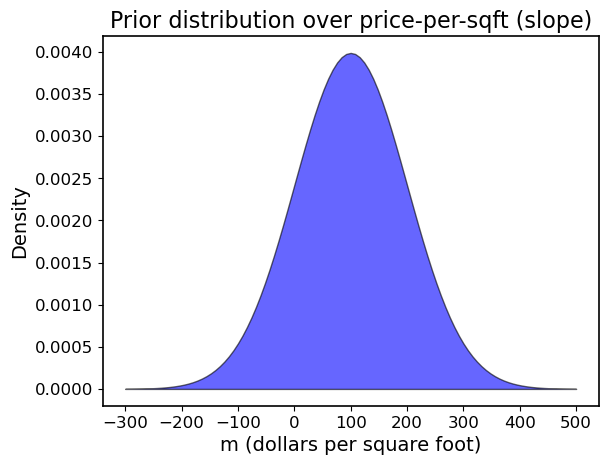

In [9]:
ms = np.linspace(-300, 500, 101) # A dense grid containing possible values for 𝑚
prior_pdf = norm.pdf(ms, mu, np.sqrt(sigma2)) # Prior PDF over the dense grid

plt.fill_between(ms, 0, prior_pdf, color="blue", alpha=0.6, edgecolor="k")
plt.title("Prior distribution over price-per-sqft (slope)")
plt.xlabel("m (dollars per square foot)")
plt.ylabel("Density")
plt.show()

In [13]:
post_sigma2 = 1 / (1 / sigma2 + (np.sum(x**2) / sigma2_noise))
post_mu = post_sigma2 * (mu / sigma2 + np.sum(x * y) / sigma2_noise)

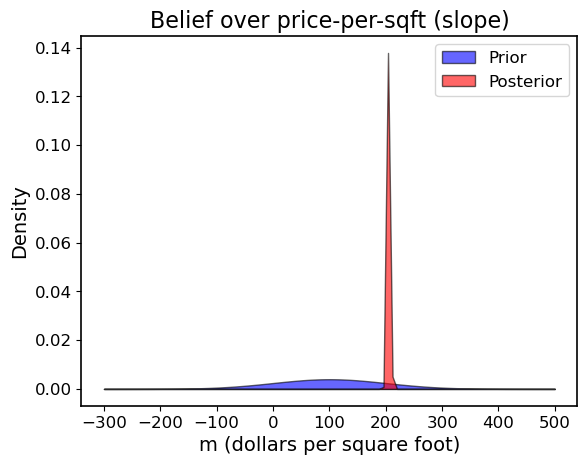

In [15]:
post_pdf = norm.pdf(ms, post_mu, np.sqrt(post_sigma2)) # Posterior PDF over the dense grid

plt.fill_between(ms, 0, prior_pdf, color="blue", alpha=0.6, edgecolor="k", label="Prior")
plt.fill_between(ms, 0, post_pdf, color="red", alpha=0.6, edgecolor="k", label="Posterior")

plt.title("Belief over price-per-sqft (slope)")
plt.xlabel("m (dollars per square foot)")
plt.ylabel("Density")
plt.legend()

plt.show()

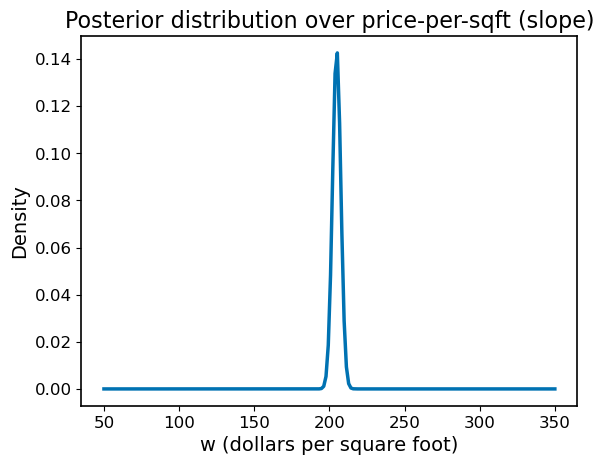

In [17]:
# Plot
w_vals = np.linspace(50, 350, 200)
post_pdf = norm.pdf(w_vals, post_mu, np.sqrt(post_sigma2))

plt.plot(w_vals, post_pdf)
plt.title("Posterior distribution over price-per-sqft (slope)")
plt.xlabel("w (dollars per square foot)")
plt.ylabel("Density")
plt.show()

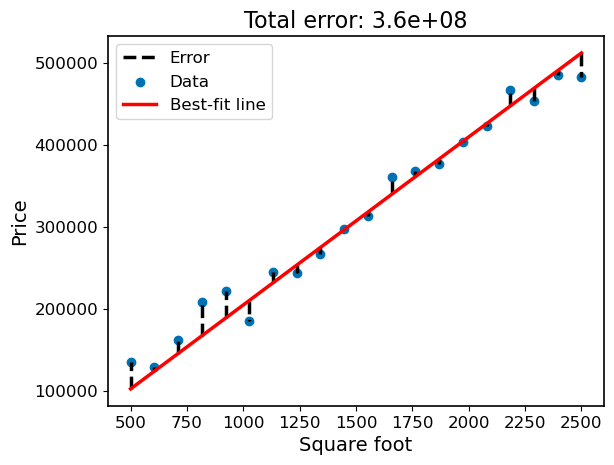

In [19]:
xs = np.linspace(500, 2500, 101)
ys = xs * post_mu

error = 0
for i, (x_i, y_i) in enumerate(zip(x, y)):
    pred_y_i = x_i * post_mu
    plt.vlines(
        x_i, 
        pred_y_i, 
        y_i, 
        linestyle="--", 
        color="k", 
        label="Error" if i == 0 else None,
    )
    error += (pred_y_i - y_i) ** 2
error /= len(x)

plt.scatter(x, y, label="Data")
plt.plot(xs, ys, c="r", label="Best-fit line")

plt.xlabel("Square foot")
plt.ylabel("Price")
plt.title(f"Total error: {error / 10**8:.1f}" + "e+08")
plt.legend()

plt.show()

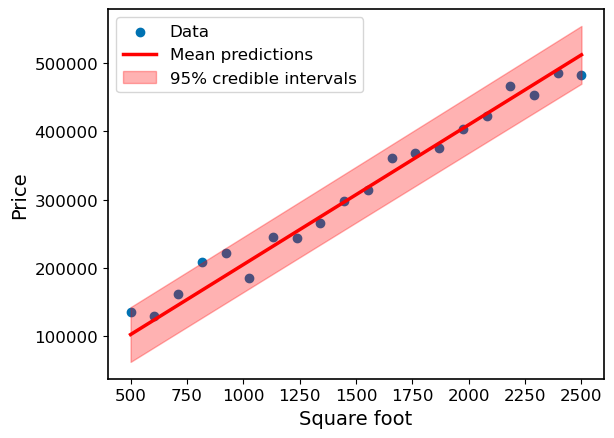

In [21]:
xs = np.linspace(500, 2500, 101)
y_mean = xs * post_mu
y_var = xs**2 * post_sigma2 + sigma2_noise
y_stddev = np.sqrt(y_var)

# error = 0
# for i, (x_i, y_i) in enumerate(zip(x, y)):
#     pred_y_i = x_i * post_mu
#     plt.vlines(
#         x_i, 
#         pred_y_i, 
#         y_i, 
#         linestyle="--", 
#         color="k", 
#         label="Error" if i == 0 else None,
#     )
#     error += (pred_y_i - y_i) ** 2
# error /= len(x)

plt.scatter(x, y, label="Data")
plt.plot(xs, y_mean, c="r", label="Mean predictions")
plt.fill_between(
    xs,
    y_mean + 2 * y_stddev,
    y_mean - 2 * y_stddev,
    color="r",
    alpha=0.3,
    label="95% credible intervals"
)

plt.xlabel("Square foot")
plt.ylabel("Price")
# plt.title(f"Total error: {error / 10**8:.1f}" + "e+08")
plt.legend()

plt.show()

(28239.56387729646, 535600.0)


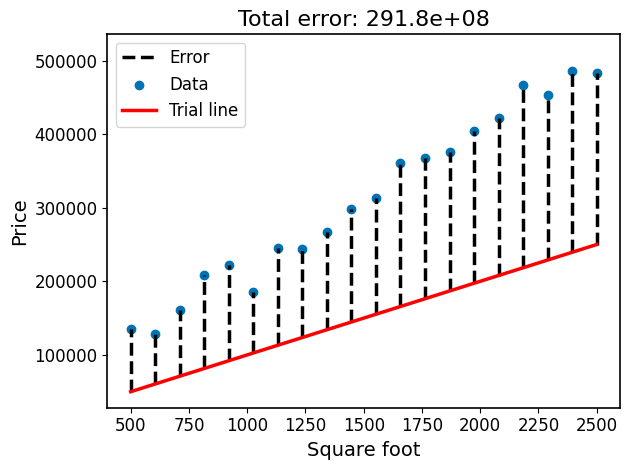

In [14]:
# slope = 206
slope = 100

xs = np.linspace(500, 2500, 101)
ys = xs * slope

error = 0
for i, (x_i, y_i) in enumerate(zip(x, y)):
    pred_y_i = x_i * slope
    plt.vlines(
        x_i, 
        pred_y_i, 
        y_i, 
        linestyle="--", 
        color="k", 
        label="Error" if i == 0 else None,
    )
    error += (pred_y_i - y_i) ** 2
error /= len(x)

plt.scatter(x, y, label="Data")
plt.plot(xs, ys, c="r", label="Trial line")

plt.xlabel("Square foot")
plt.ylabel("Price")
plt.title(f"Total error: {error / 10**8:.1f}" + "e+08")
plt.legend()

plt.ylim(28239.56387729646, 535600.0)
print(plt.ylim())

plt.tight_layout()
plt.show()

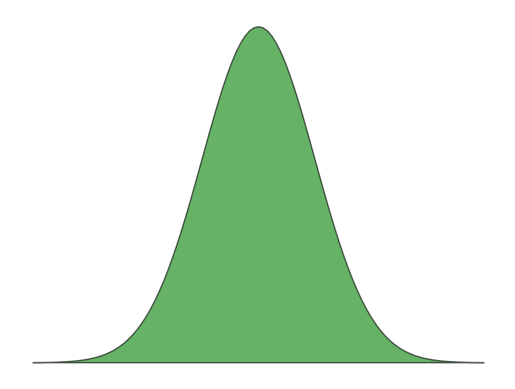

In [6]:
plt.fill_between(ms, 0, prior_pdf, color="green", alpha=0.6, edgecolor="k")
# plt.fill_between(ms, 0, norm.pdf(ms, post_mu, np.sqrt(post_sigma2)), color="red", alpha=0.6, edgecolor="k")
plt.axis("off")
plt.show()